- load indivdual datasets
- examine datasets and experiment
- what graphs and charts will be useful?
- I like my two graphics.  What else can I visualize?
- what other interesting research questions can I ask? The correlation of genre or production company to flop seemed bunk. I think partly because my data is junky

- clean up data
    - already cleaned up the credits csv
    - fill n/a for blank or values that are zero ie. revenue or budget
    - clear out junk data from is_adult column
    - maybe create a whole separate file for cleaning / pre-processing
    - do i need to drop duplicates?  I noticed at least one duplicate movie.

- Guidelines for Project Specification

- Data Description
- Research Questions

- Data Analysis
    - Overall Summary
    - Group Analysis
    - Time Series
    - Visualization of Distributions
    - Time series visualization
    - Other visualizations

- what ML techniques should I use?
    - Need at least one Unsupervised task
    - Need at least one Supervised task

- notes from Dr. Gruppi:
```Great!

Try to keep in mind strategies to handle missing/garbage data. For instance, will you drop rows that contain poor-quality data?

Your list probably has a lage number of actors. Regarding your last question -- do actors _guarantee_ the success of the film or do they simply __correlate__ with success? That is, if a high profile actor is cast in a movie, chances are that the whole production is also huge, this includes advertising and media presence. Just some food for thought! Remember: correlation does not mean causation!
```

```Todo:

- create powerpoint
- create acm styled report (8 page max)
- write a meaningful readme, describe files included and any instructions
- drop dupes
- Unsupervised task
- Supervised task
    - word embedding / svm.  genre prediction ?
```

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

movies_df = pd.read_csv("Datasets/clean_movies.csv")
cast_df = pd.read_csv("Datasets/clean_cast.csv")
crew_df = pd.read_csv("Datasets/clean_crew.csv")
keyword_df = pd.read_csv("Datasets/clean_keyword.csv")
genres_df = pd.read_csv("Datasets/clean_genres.csv")
production_df = pd.read_csv("Datasets/clean_production.csv")



In [2]:
#inspect the cleaned data

data_frames = {
    "movies_df": movies_df,
    "cast_df": cast_df,
    "crew_df": crew_df,
    "keyword_df": keyword_df,
    "genres_df": genres_df,
    "production_df": production_df
}

for name, df in data_frames.items():
    print(f"\n" + "*"*55)
    print(f" {name} Head")
    print("*"*55)
    print(df.head())
    
    print(f"\n" + "*"*55)
    print(f" {name} Info")
    print("*"*55)
    df.info()
    print("*"*55)



*******************************************************
 movies_df Head
*******************************************************
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toysto

In [3]:
#Figure out what the mean profit/popularity is

movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
profit_avg = movies_df['profit'].mean().round(2)
pop_avg = movies_df['popularity'].mean()

print(f"The average profit from this collection is ${profit_avg}")
print(f"The average popularity from this collection is {pop_avg}")

# under_movies_df = movies_df[(movies_df['profit'] < profit_avg) & (movies_df['popularity'] < pop_avg)]


The average profit from this collection is $6984490.94
The average popularity from this collection is 2.9214783449186092


In [4]:
#What constitutes a flop or a low performing film?

#Is it popularity?  

#Drop any row with popularity = 0 and with vote counts less than 100.  This will eliminate blanks and films with low vote counts.

movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 100)]

#List the top 100 least popular movies

least_popular = movies_df.sort_values('popularity').head(100)

least_popular[['original_title', 'popularity', 'vote_count']]

,original_title,popularity,vote_count
25717,蛍火の杜へ,0.005007,105.0
5553,火垂るの墓,0.010902,974.0
23470,Tracks,0.239993,190.0
36453,Les Profs,0.240446,367.0
25355,Bring It On: In It To Win It,0.252987,114.0
...,...,...,...
44883,Notte prima degli esami - Oggi,4.345520,137.0
1521,Picture Perfect,4.347079,114.0
25794,Il ragazzo invisibile,4.349915,170.0
10101,Lords of Dogtown,4.350049,215.0


In [5]:
#From this top 100 list what are the agreed upon least popular films?

rotten_tomato = least_popular.sort_values('vote_count', ascending=False).head(100)
rotten_tomato[['original_title', 'popularity', 'vote_count']]

,original_title,popularity,vote_count
20969,Fast & Furious 6,1.657637,5282.0
17217,X-Men: First Class,0.738633,5252.0
586,The Silence of the Lambs,4.307222,4549.0
3671,X-Men,0.954467,4172.0
21295,The Wolverine,3.918287,4110.0
...,...,...,...
286,Once Were Warriors,4.025276,106.0
25717,蛍火の杜へ,0.005007,105.0
25896,Doodlebug,3.729927,105.0
44451,Il secondo tragico Fantozzi,4.232902,105.0


In [6]:
#Is a flop a film that lost money?

#drop any film with budget or revenue equal to 0 to eliminate noise

movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]
movies_df.sort_values('revenue').head(100)



,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,profit
19344,False,NaN,3000000,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",NaN,89691,tt1603257,en,ATM,"On a late night visit to an ATM, three co-work...",...,3010.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,No warning. No control. No escape.,ATM,False,5.1,195.0,-2996990.0
43203,False,NaN,10500000,"[{'id': 18, 'name': 'Drama'}, {'id': 53, 'name...",NaN,390051,tt4581576,en,Aftermath,A fatal plane crash changes the lives of Roman...,...,3451.0,92.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,All he had left was revenge,Aftermath,False,5.8,162.0,-10496549.0
3447,False,"{'id': 498, 'name': 'Heart of Gold Collection'...",2500000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",http://www.dogme95.dk/the_idiots/content/index...,452,tt0154421,da,Idioterne,With his first Dogma-95 film director Lars von...,...,7235.0,117.0,"[{'iso_639_1': 'da', 'name': 'Dansk'}]",Released,NaN,The Idiots,False,6.7,107.0,-2492765.0
23954,False,NaN,4000000,"[{'id': 27, 'name': 'Horror'}, {'id': 9648, 'n...",NaN,211067,tt2383068,en,The Sacrament,A fashion photographer is traveling to meet hi...,...,9221.0,99.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Documented for the first time witness the unto...,The Sacrament,False,5.6,139.0,-3990779.0
24085,False,NaN,1000000,"[{'id': 27, 'name': 'Horror'}]",NaN,254191,tt3177316,en,Honeymoon,A newlywed couple finds their lake-country hon...,...,9318.0,87.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,After the ceremony comes the ritual.,Honeymoon,False,5.4,261.0,-990682.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13310,False,NaN,2600000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",http://www.cronocrimenes.com/,14139,tt0480669,es,Los cronocrímenes,A man accidentally gets into a time machine an...,...,553198.0,92.0,"[{'iso_639_1': 'es', 'name': 'Español'}]",Released,A trip back in time from the present to...,Timecrimes,False,7.0,313.0,-2046802.0
13331,False,NaN,9750000,"[{'id': 18, 'name': 'Drama'}, {'id': 53, 'name...",http://www.sonypictures.com/movies/thelazarusp...,13825,tt0464041,en,The Lazarus Project,After Ben Garvey foolishly turned back to crim...,...,558000.0,99.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Cheating death is only the beginning,The Lazarus Project,False,6.0,116.0,-9192000.0
99,False,NaN,7000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 80, 'nam...",NaN,13685,tt0115734,en,Bottle Rocket,Upon his release from a mental hospital follow...,...,560069.0,91.0,"[{'iso_639_1': 'es', 'name': 'Español'}, {'iso...",Released,"They're not really criminals, but everyone's g...",Bottle Rocket,False,6.8,285.0,-6439931.0
11182,False,NaN,12000000,"[{'id': 14, 'name': 'Fantasy'}, {'id': 18, 'na...",http://www.tidelandthemovie.com/,11559,tt0410764,en,Tideland,Because of the actions of her irresponsible pa...,...,566611.0,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The squirrels made it seem less lonely.,Tideland,False,6.3,147.0,-11433389.0


In [7]:
movies_df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,profit
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,343554033.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,197797249.0
5,False,NaN,60000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0,127436818.0
8,False,NaN,35000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,9091,tt0114576,en,Sudden Death,International action superstar Jean Claude Van...,...,64350171.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Terror goes into overtime.,Sudden Death,False,5.5,174.0,29350171.0
9,False,"{'id': 645, 'name': 'James Bond Collection', '...",58000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.mgm.com/view/movie/757/Goldeneye/,710,tt0113189,en,GoldenEye,James Bond must unmask the mysterious head of ...,...,352194034.0,130.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,No limits. No fears. No substitutes.,GoldenEye,False,6.6,1194.0,294194034.0


In [8]:
#Search for films with a large difference between budget and revenue.

print("These are the least profitable films.")

least_profitable = movies_df.sort_values('profit').head(100)
least_profitable[['original_title', 'budget', 'revenue', 'profit']]

These are the least profitable films.


,original_title,budget,revenue,profit
21174,The Lone Ranger,255000000,89289910.0,-165710090.0
7226,The Alamo,145000000,25819961.0,-119180039.0
16788,Mars Needs Moms,150000000,38992758.0,-111007242.0
44334,Valerian and the City of a Thousand Planets,197471676,90024292.0,-107447384.0
2711,The 13th Warrior,160000000,61698899.0,-98301101.0
...,...,...,...,...
42211,King Arthur: Legend of the Sword,175000000,146175066.0,-28824934.0
2203,Practical Magic,75000000,46683377.0,-28316623.0
13719,The Soloist,60000000,31720158.0,-28279842.0
36145,The Finest Hours,80000000,52099090.0,-27900910.0


In [9]:
#Are there any films that are in the top 500 least popular and top 500 least profitable?

least_popular= movies_df.sort_values('popularity').head(500)
least_profitable = movies_df.sort_values('profit').head(500)

overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

print("And the bigest losers are...")
print(f"There are {len(overlap)} movies that are in both top 500 least popular and least profitable lists.")      
overlap[['original_title', 'budget', 'revenue', 'popularity', 'profit']]

And the bigest losers are...
There are 91 movies that are in both top 500 least popular and least profitable lists.


,original_title,budget,revenue,popularity,profit
20931,The Internship,58000000,44000000.0,0.393865,-14000000.0
9279,特務迷城,25697387,3849941.0,3.136813,-21847446.0
10101,Lords of Dogtown,25000000,13411957.0,4.350049,-11588043.0
4737,Riding in Cars with Boys,48000000,35743308.0,4.556123,-12256692.0
4033,3000 Miles to Graceland,62000000,18720175.0,4.764480,-43279825.0
...,...,...,...,...,...
12325,Flawless,20000000,6819587.0,6.496913,-13180413.0
730,The Arrival,25000000,14048372.0,6.497591,-10951628.0
10701,BloodRayne,25000000,2405420.0,6.514132,-22594580.0
6111,Boat Trip,20000000,8586376.0,6.515316,-11413624.0


In [10]:
#And now from the overlap, what are the agreed upon least popular and least profitable films

rotten_tomato = overlap.sort_values('vote_count', ascending=False).head(100)
rotten_tomato[['original_title', 'popularity', 'vote_count', 'profit']]

,original_title,popularity,vote_count,profit
20931,The Internship,0.393865,1691.0,-14000000.0
19822,Red Dawn,5.627787,573.0,-20193217.0
17296,Your Highness,5.673750,511.0,-23778362.0
10369,Domino,6.394143,450.0,-27055498.0
19047,A Thousand Words,5.446745,381.0,-17955723.0
...,...,...,...,...
4737,Riding in Cars with Boys,4.556123,108.0,-12256692.0
5422,FearDotCom,5.160215,106.0,-21097985.0
12316,디워,6.280906,104.0,-16412596.0
18721,The Ledge,4.883085,103.0,-9389014.0


In [11]:
#widening the overlap to get more potential matches:

least_popular= movies_df.sort_values('popularity').head(1000)
least_profitable = movies_df.sort_values('profit').head(1000)

overlap = least_popular[least_popular['id'].isin(least_profitable['id'])]

#Now let's identify cast and crew that are responsible for creating flops

cast_overlap = pd.merge(overlap, cast_df, left_on='id', right_on='movie_id')
crew_overlap = pd.merge(overlap, crew_df, left_on='id', right_on='movie_id')

print(cast_overlap[['title', 'actor_name', 'character']])
print(crew_overlap[['title', 'crew_name', 'job', 'department']])


          title         actor_name               character
0     Manhunter   William Petersen             Will Graham
1     Manhunter         Kim Greist            Molly Graham
2     Manhunter      Dennis Farina           Jack Crawford
3     Manhunter          Brian Cox    Dr. Hannibal Lecktor
4     Manhunter         Joan Allen            Reba McClane
...         ...                ...                     ...
7884     Stolen  Marcus Lyle Brown                Matthews
7885     Stolen        M.C. Gainey                    Hoyt
7886     Stolen  Bernadette Ralphs              Kiosk Girl
7887     Stolen         Emily West  Frightened Girl in Car
7888     Stolen          Tom Waite  FBI Agent (uncredited)

[7889 rows x 3 columns]
          title          crew_name                job         department
0     Manhunter     Colleen Atwood     Costume Design  Costume & Make-Up
1     Manhunter       Michael Mann         Screenplay            Writing
2     Manhunter       Michael Mann           Dir

In [12]:
#Are any cast or crew involved in one or more flops?
#I made sure to get unique values.  The same actor or crew member could have multiple jobs
flop_actors = cast_overlap.groupby('actor_name')['id'].nunique().sort_values(ascending=False)

print("Number of flops per actor")
print(flop_actors.head(20))


flop_crew = crew_overlap.groupby('crew_name')['id'].nunique().sort_values(ascending=False)

print("Number of flops per crew member")
print(flop_crew.head(20))

Number of flops per actor
actor_name
Paul Giamatti          9
Samuel L. Jackson      9
Steve Buscemi          6
Forest Whitaker        6
Nicole Kidman          6
Matt Damon             6
John C. Reilly         6
Melanie Lynskey        6
Christian Slater       6
Stephen Root           6
Matthew McConaughey    5
Naomi Watts            5
Jon Lovitz             5
John Goodman           5
Anjelica Huston        5
Michael Shannon        5
Robert De Niro         5
Margo Martindale       5
John Leguizamo         5
Shea Whigham           5
Name: id, dtype: int64
Number of flops per crew member
crew_name
Avy Kaufman          10
Tricia Wood           9
Mark Isham            9
Elie Samaha           7
Deborah Aquila        7
Bill Pankow           6
Toby Emmerich         6
Brian Tyler           6
Avi Lerner            6
Mary Vernieu          6
Joel Silver           6
Mark Gordon           6
Graeme Revell         5
Alan Silvestri        5
Brian De Palma        5
Deirdre Bowen         5
Dante Spinotti

In [13]:

#What low performing movies were these actors in?

bad_actors = cast_overlap['actor_name'].value_counts().head(5).index.tolist()

bad_movies = cast_overlap[cast_overlap['actor_name'].isin(bad_actors)]

for actor in bad_actors:
    print(f"\nActor: {actor}")
    print(bad_movies[bad_movies['actor_name'] == actor][['title', 'character', 'popularity', 'profit']])


Actor: Samuel L. Jackson
                 title                     character  popularity      profit
1179           Twisted                    John Mills    5.376246 -24805000.0
2116        The Spirit                      Octopuss    5.762005 -20968663.0
3765   One Eight Seven               Trevor Garfield    6.476493 -14283920.0
5343          Big Game  President William Alan Moore    6.911759  -1000000.0
5779        Hard Eight                         Jimmy    7.047560  -2777441.0
5817  Black Snake Moan                       Lazarus    7.050403  -4096154.0
5968            Sphere               Dr. Harry Adams    7.124735 -61900000.0
7491    The Negotiator               Lt. Danny Roman    7.655020  -5452319.0
7809    The Red Violin    Charles Morritz (Montréal)    7.725843  -8504592.0

Actor: Paul Giamatti
                     title           character  popularity      profit
277                Win Win       Mike Flaherty    4.480723   -176788.0
1474            Fred Claus  Nick (Santa)

In [14]:
#What low performing movies were these crew members in?
#I needed to make sure to that the movies were unique.  For instance if a director was also a writer then they could be double counted.

bad_crew = crew_overlap.groupby('crew_name')['id'].nunique().sort_values(ascending=False).head(5).index.tolist()

bad_movies_crew = crew_overlap[crew_overlap['crew_name'].isin(bad_crew)]

for member in bad_crew:
    print(f"\nCrew Member: {member}")
    print(bad_movies_crew[bad_movies_crew['crew_name'] == member][['title', 'job', 'popularity', 'profit']])



Crew Member: Avy Kaufman
                          title      job  popularity      profit
258                   The Ledge  Casting    4.883085  -9389014.0
789             My Soul to Take  Casting    5.282976  -5170043.0
1477            The Conspirator  Casting    5.481452  -9521200.0
1552                 The Beaver  Casting    5.484379 -20029184.0
2079                Jersey Girl  Casting    5.706507   1098382.0
3118            Wish I Was Here  Casting    6.149295    -16701.0
6911                      Awake  Casting    7.076062 -71626175.0
7284              The Ice Storm  Casting    7.146352  -9961939.0
8945           Land of the Lost  Casting    7.642063 -31311169.0
9376  Everything is Illuminated  Casting    7.738924  -4302070.0

Crew Member: Tricia Wood
                             title      job  popularity      profit
484   Tomorrow, When the War Began  Casting    4.983475 -10495064.0
662              The Vatican Tapes  Casting    5.149301 -11215237.0
1939                   Wicker

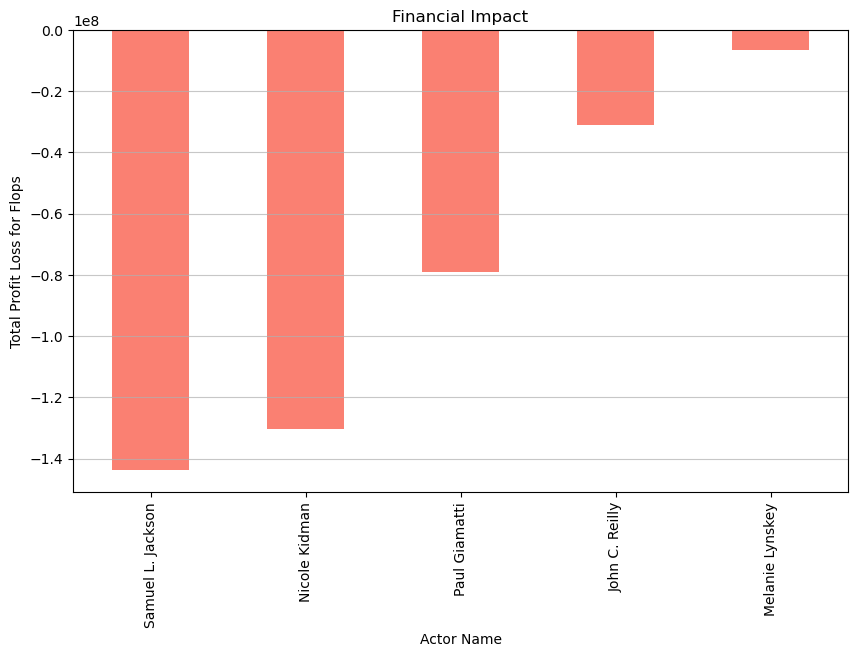

In [15]:
#create a side by side visualization (line graph)? of money lost by the "top 5" cast and crew

actor_loss = bad_movies.groupby('actor_name')['profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
actor_loss.plot(kind='bar', color='salmon')

plt.title('Financial Impact')
plt.ylabel('Total Profit Loss for Flops')
plt.xlabel('Actor Name')
plt.grid(axis='y', alpha=0.7)

plt.show()



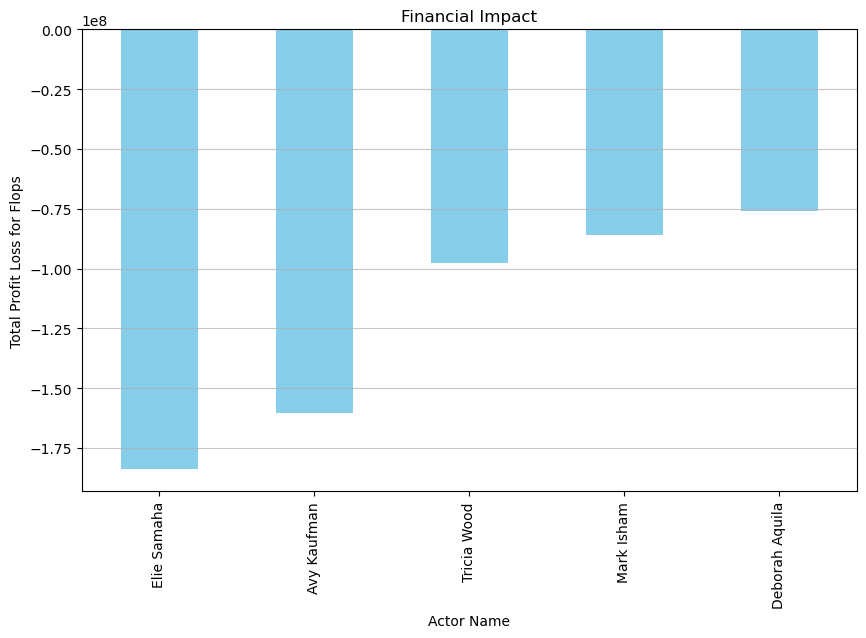

In [16]:
crew_loss = bad_movies_crew.groupby('crew_name')['profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
crew_loss.plot(kind='bar', color='skyblue')

plt.title('Financial Impact')
plt.ylabel('Total Profit Loss for Flops')
plt.xlabel('Actor Name')
plt.grid(axis='y', alpha=0.7)

plt.show()

In [17]:
#supervised task
#ideas??

In [18]:
#unsupervised task
#ideas??